In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Downloads/archive (1)/college_major_roi.csv")

print(df.shape)

(30000, 18)


 v HANDLING MISSING VALUES v

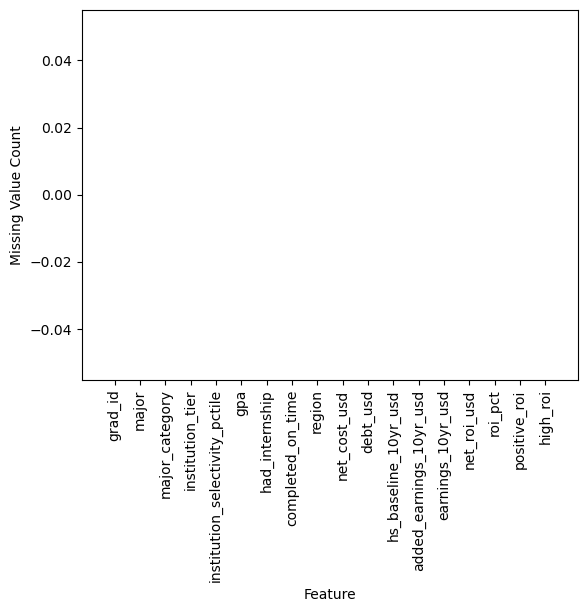

The total missing values: 0
No missing values found.


In [30]:
x = df.isnull().sum()

plt.bar(x.index, x.values)
plt.xlabel('Feature')
plt.ylabel('Missing Value Count')
plt.xticks(rotation=90)
plt.show()

print("The total missing values:", x.sum())

if x.sum() > 0:
    print("Missing values were found.")
else:
    print("No missing values found.")

v HANDLING DUPLICATES v

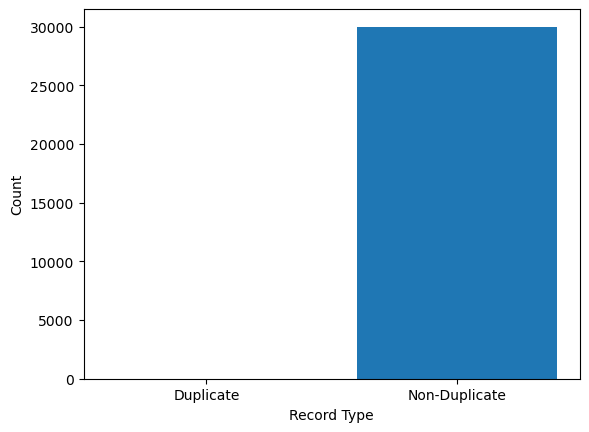

Total duplicate records: 0


In [33]:
x = ['Duplicate', 'Non-Duplicate']
y = [df.duplicated().sum(), len(df) - df.duplicated().sum()]

plt.bar(x, y)
plt.xlabel('Record Type')
plt.ylabel('Count')
plt.show()

print("Total duplicate records:", df.duplicated().sum())

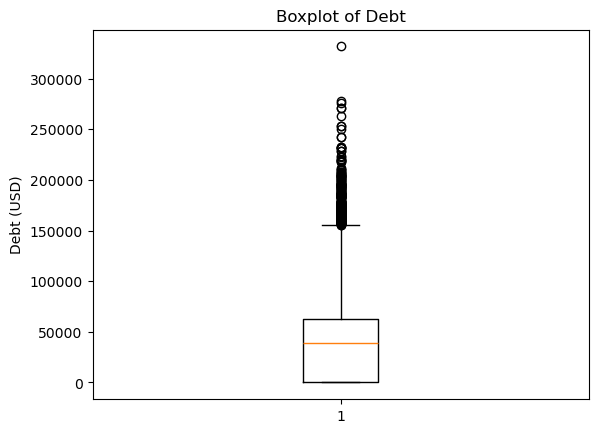

In [17]:
plt.boxplot(df['debt_usd'])
plt.ylabel('Debt (USD)')
plt.title('Boxplot of Debt')
plt.show()

v FEATURE DISTRIBUTION v

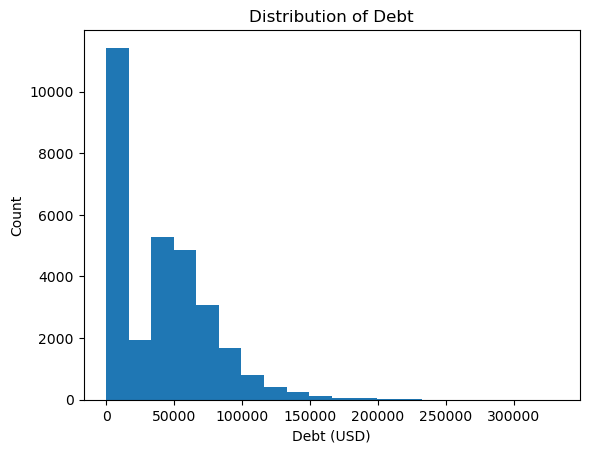

In [18]:
plt.hist(df['debt_usd'], bins=20)
plt.xlabel('Debt (USD)')
plt.ylabel('Count')
plt.title('Distribution of Debt')
plt.show()

v SKEWNESS v

In [25]:
print("Debt skewness:", df['debt_usd'].skew())
print("Net cost skewness:", df['net_cost_usd'].skew())

Debt skewness: 0.8868074303663452
Net cost skewness: 1.5686735942057046


v CORRELATION v

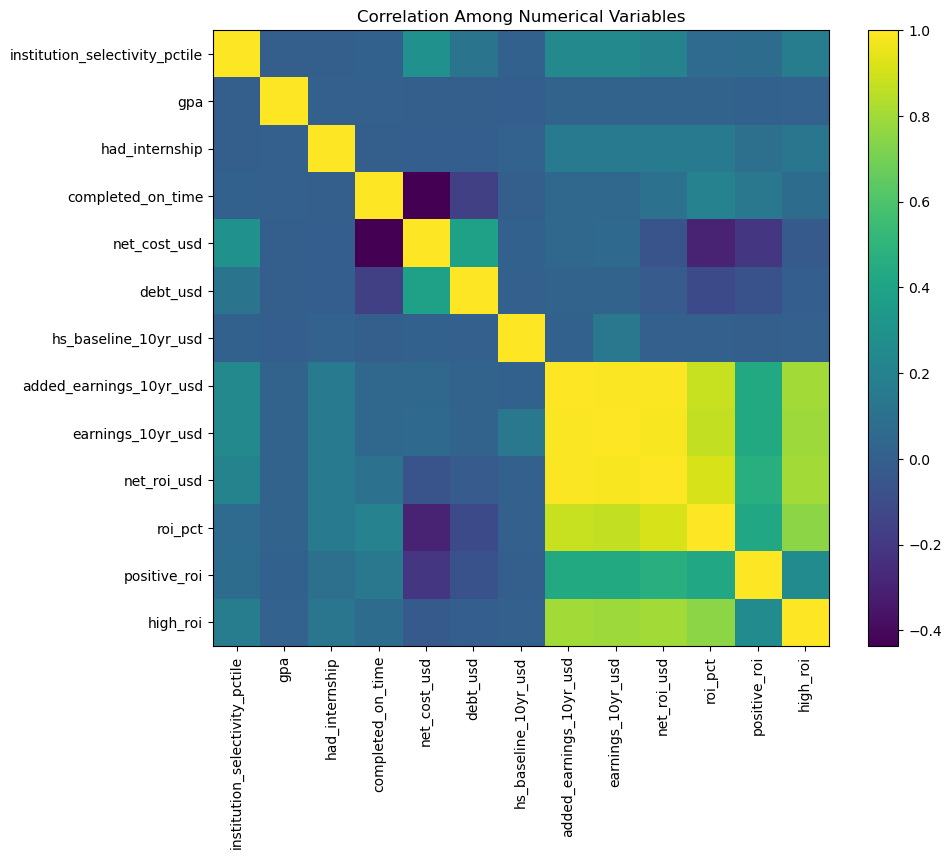

In [20]:
x = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
plt.imshow(x)
plt.colorbar()

plt.xticks(range(len(x.columns)), x.columns, rotation=90)
plt.yticks(range(len(x.columns)), x.columns)

plt.title('Correlation Among Numerical Variables')
plt.show()

v CLASS DISTRIBUTION v

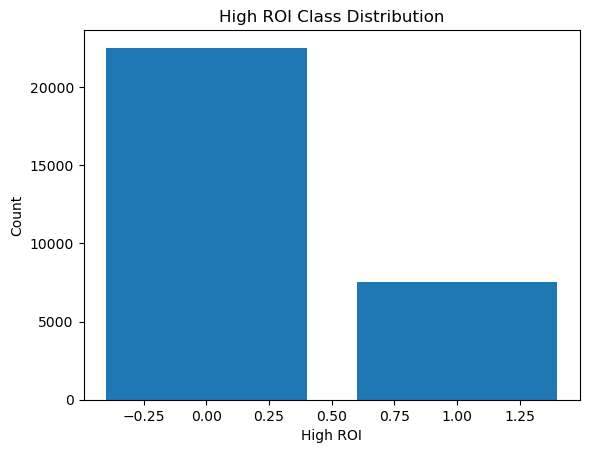

Class percentages:
high_roi
0    75.0
1    25.0
Name: proportion, dtype: float64


In [21]:
x = df.high_roi.value_counts()

plt.bar(x.index, x.values)
plt.xlabel('High ROI')
plt.ylabel('Count')
plt.title('High ROI Class Distribution')
plt.show()

print("Class percentages:")
print(df.high_roi.value_counts(normalize=True) * 100)

v HANDLING NOISES v

In [22]:
print(df['major'].unique())
print(df['major_category'].unique())
print(df['institution_tier'].unique())
print(df['region'].unique())

['biology' 'marketing' 'electrical_engineering' 'business' 'economics'
 'social_work' 'mechanical_engineering' 'finance' 'computer_engineering'
 'education' 'chemical_engineering' 'communications' 'computer_science'
 'nursing' 'criminal_justice' 'fine_arts' 'humanities' 'psychology'
 'business_analytics']
['STEM' 'business' 'social_science' 'education' 'health' 'arts'
 'humanities']
['mid_tier' 'top_public' 'ivy_elite' 'regional' 'for_profit']
['south' 'northeast' 'midwest' 'west']


v DATA INCONSISTENCY v

In [23]:
print("GPA below 0:", (df['gpa'] < 0).sum())
print("GPA above 4:", (df['gpa'] > 4).sum())
print("Negative debt:", (df['debt_usd'] < 0).sum())
print("Negative cost:", (df['net_cost_usd'] < 0).sum())

GPA below 0: 0
GPA above 4: 0
Negative debt: 0
Negative cost: 0


v STATISTICAL SUMMARY v

In [24]:
print(df.describe())

       institution_selectivity_pctile           gpa  had_internship  \
count                    30000.000000  30000.000000    30000.000000   
mean                        55.086067      3.093337        0.436067   
std                         18.593708      0.439060        0.495904   
min                         16.000000      1.500000        0.000000   
25%                         42.000000      2.790000        0.000000   
50%                         55.000000      3.100000        0.000000   
75%                         68.000000      3.400000        1.000000   
max                        102.000000      4.000000        1.000000   

       completed_on_time   net_cost_usd       debt_usd  hs_baseline_10yr_usd  \
count       30000.000000   30000.000000   30000.000000          30000.000000   
mean            0.682367   88621.496667   38498.063333         359893.416667   
std             0.465564   33576.903160   37801.748200          39923.943255   
min             0.000000   28500.000000 